# סיווג קטגוריות חדשות מטקסט — NLP + Naive Bayes

**מטלה בלמידת מכונה**

| | |
|---|---|
| **Assignment Type** | NLP |
| **Learning Type** | Classification (multi-class, 20 מחלקות) |
| **Algorithm** | Multinomial Naive Bayes |
| **Dataset** | [News Category Dataset](https://www.kaggle.com/datasets/rmisra/news-category-dataset) — HuffPost, 209,527 כותרות |
| **מדד ההצלחה** | Macro-Average F1 |

### ייחוס ה-Dataset (רישיון CC BY 4.0 — ייחוס הוא תנאי של הרישיון)

> Misra, Rishabh. "News Category Dataset." *arXiv preprint arXiv:2209.11429* (2022).
>
> Misra, Rishabh and Jigyasa Grover. "Sculpting Data for ML: The first act of Machine Learning." (2021).

---
### למה Naive Bayes מתאים למשימה הזאת?

הטקסט מיוצג כ-bag-of-words בוקטור TF-IDF דליל ובעל ממד גבוה (20,000 features).
Naive Bayes מניח אי-תלות בין ה-features בהינתן המחלקה — הנחה שגויה בעליל
בשפה טבעית (המילים "trump" ו-"president" תלויות זו בזו) — ובכל זאת הוא עובד
טוב מאוד על טקסט: הוא מתאמן בשניות, לא עושה overfit על ממד גבוה,
**ובעיקר הוא שקוף לחלוטין** — כל ההחלטה שלו נגזרת מ-log P(word|class),
ולכן אפשר לקרוא את ההסבר ישירות מהפרמטרים (ראו חלק 6.ג).

In [1]:
import sys
import os
import warnings

# הרצה מתוך notebooks/ — נוסיף את src ל-path ונעבור לשורש הפרויקט
_here = os.getcwd()
ROOT = os.path.abspath(os.path.join(_here, ".." if os.path.basename(_here) == "notebooks" else "."))
os.chdir(ROOT)
sys.path.insert(0, os.path.join(ROOT, "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# viz בוחר backend לפי הסביבה: inline ב-Jupyter, Agg בטרמינל.
import viz
viz.apply_style()
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
print("סביבה מוכנה. שורש הפרויקט:", ROOT)

סביבה מוכנה. שורש הפרויקט: C:\src\llm_task


## חלק 1 — טעינת ה-Dataset וסקירה כללית

In [2]:
from data_loader import (load_raw_data, reduce_to_top_classes, describe_dataset,
                         split_train_test, LABEL_COL)

raw = load_raw_data()
print(f"נטענו {len(raw):,} רשומות, {raw[LABEL_COL].nunique()} קטגוריות")
raw.head(3)

נטענו 209,527 רשומות, 42 קטגוריות


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23


### צמצום ל-20 המחלקות הגדולות

ה-dataset המקורי מכיל 42 קטגוריות. אנחנו מצמצמים ל-20 הגדולות משתי סיבות:
התיישרות עם מפרט המטלה (multi-class, 20 מחלקות), ומחלקות הזנב מכילות
פחות מ-1,100 דוגמאות כל אחת — מעט מדי ללמידה אמינה.

In [3]:
df = reduce_to_top_classes(raw)


צמצום מחלקות: 42 -> 20 מחלקות
מספר שורות: 209527 -> 166057 (79.3% מהנתונים נשמרו)
המחלקות שנשמרו: ['BLACK VOICES', 'BUSINESS', 'COMEDY', 'CRIME', 'ENTERTAINMENT', 'FOOD & DRINK', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT', 'PARENTING', 'PARENTS', 'POLITICS', 'QUEER VOICES', 'SPORTS', 'STYLE & BEAUTY', 'THE WORLDPOST', 'TRAVEL', 'WEDDINGS', 'WELLNESS', 'WOMEN']


In [4]:
describe_dataset(df)

מספר שורות (כותרות חדשות): 166057
מספר עמודות: 6
עמודות: ['link', 'headline', 'category', 'short_description', 'authors', 'date']
מספר מחלקות category ייחודיות: 20

התפלגות מחלקות (5 הגדולות):
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
Name: count, dtype: int64

התפלגות מחלקות (5 הקטנות):
category
THE WORLDPOST    3664
WEDDINGS         3653
WOMEN            3572
CRIME            3562
IMPACT           3484
Name: count, dtype: int64

5 השורות הראשונות של ה-dataset:
                                            headline                                  short_description       category
0  23 Of The Funniest Tweets About Cats And Dogs ...  "Until you have a dog you don't understand wha...         COMEDY
1  The Funniest Tweets From Parents This Week (Se...  "Accidentally put grown-up toothpaste on my to...      PARENTING
2  Maury Wills, Base-Stealing Shortstop For Dodge...  Maury Wills, who helped the Los Ang

  short_description: 13030


### התפלגות המחלקות — חוסר האיזון

זהו נתון מרכזי לכל ההמשך: היחס בין המחלקה הגדולה לקטנה הוא כ-**10x**.
בגלל זה בחרנו ב-macro-F1 ולא ב-accuracy: accuracy "מתגמל" מודל שמנחש
טוב רק את POLITICS ומתעלם מהמחלקות הקטנות, ואילו macro-F1 נותן משקל
שווה לכל מחלקה ללא תלות בגודלה.

התפלגות מחלקות (מהגדולה לקטנה):
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
Name: count, dtype: int64

המחלקה הגדולה: POLITICS (35,602 דוגמאות)
המחלקה הקטנה : IMPACT (3,484 דוגמאות)
יחס בין הגדולה לקטנה: 10.2x


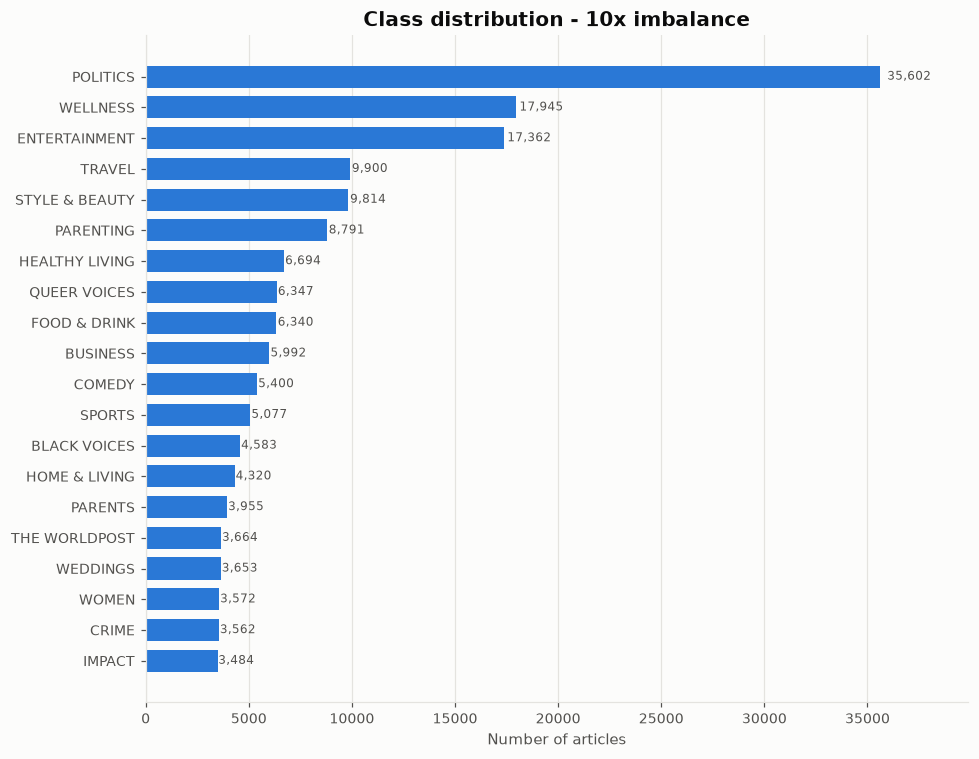

In [5]:
from extensions import show_class_imbalance, plot_class_distribution

counts = show_class_imbalance(df)
plot_class_distribution(df, save_path=None)
plt.show()

### חלוקה ל-Train / Test

חלוקה 80/20 עם **סטרטיפיקציה** לפי התווית, כדי שיחסי המחלקות יישמרו
בשתי הקבוצות. בלי סטרטיפיקציה, מחלקה קטנה עלולה לקבל ייצוג שונה מאוד
ב-test וה-macro-F1 היה הופך לרועש.

In [6]:
train_df, test_df = split_train_test(df)


גודל train: 132845 | גודל test: 33212


## חלק 2 — Feature Engineering

הצינור: headline + short_description → ניקוי טקסט → TF-IDF.

**הכלל המתודולוגי החשוב:** ה-vectorizer עושה fit **רק על ה-train**.
על ה-test מבצעים transform בלבד. אחרת המילון והמשקלים היו "רואים"
את ה-test ונוצרת דליפת מידע (data leakage) שמנפחת את התוצאות.

In [7]:
from feature_engineering import show_before_after_examples, build_tfidf_features

show_before_after_examples(train_df, n=3)

לפני  (headline): We're Gonna Train 'Em: The Fallacy of American Total Make-Over in Iraq
לפני  (desc)    : What were/are we training Iraqis for? Should not the training, for a country we knew nothing about but were trying to "save," have been the other way around?
אחרי  (מאוחד)   : we re gonna train em the fallacy of american total make over in iraq what were are we training iraqis for should not the training for a country we knew nothing about but were trying to save have been the other way around
----------------------------------------------------------------------
לפני  (headline): A Currency Chapter in the TPP Will Not Diminish our Fed's Independence
לפני  (desc)    : I'm sympathetic to the notion that since we already have lower tariffs than our trading partners, there are gains to be made on this front. But if the negotiators are truly saying we simply cannot have a trade deal that blocks currency managers, then maybe we shouldn't have a trade deal.
אחרי  (מאוחד)   : a currency 

### בחירות התכנון ב-TF-IDF

| פרמטר | ערך | נימוק |
|---|---|---|
| stop_words | "english" | בכותרות חדשות יש המון מילות תפקוד ("the", "of") שאינן נושאות אינפורמציה על הקטגוריה |
| ngram_range | (1, 2) | ביגרמים לוכדים צירופים בעלי משמעות כמו "donald trump" או "tom brady" |
| min_df | 2 | מסיר מילים שמופיעות פעם אחת בכל הקורפוס (שמות פרטיים, שגיאות כתיב) |
| sublinear_tf | True | ממתן מילים שחוזרות הרבה פעמים באותו מסמך |
| max_features | 20000 | תקרה על גודל המילון |

In [8]:
X_train, X_test, vectorizer, train_df, test_df = build_tfidf_features(train_df, test_df)
y_train, y_test = train_df[LABEL_COL], test_df[LABEL_COL]

density = X_train.nnz / (X_train.shape[0] * X_train.shape[1])
print(f"צורת מטריצת train: {X_train.shape}")
print(f"צורת מטריצת test : {X_test.shape}")
print(f"צפיפות המטריצה   : {density:.5f}  (מטריצה דלילה מאוד)")
print()
print("20 features לדוגמה:", list(vectorizer.get_feature_names_out()[5000:5020]))

גודל המילון (features): 20000
צורת מטריצת train: (132845, 20000)
צורת מטריצת test : (33212, 20000)
צפיפות המטריצה   : 0.00078  (מטריצה דלילה מאוד)

20 features לדוגמה: ['doom', 'doomed', 'door', 'doors', 'dope', 'doping', 'doppelg', 'doritos', 'dorm', 'dorothy', 'dorsey', 'dos', 'dos don', 'dose', 'dose political', 'doses', 'dot', 'dots', 'double', 'double standard']


## חלקים 3–4 — מימוש Naive Bayes ואימון

TextNaiveBayes הוא wrapper סביב MultinomialNB שחושף שני hyperparameters:
alpha (החלקת Laplace/Lidstone) ו-fit_prior.

**הערת תאימות ל-sklearn:** לפי הקונבנציה, __init__ רק שומר פרמטרים ואינו
בונה אובייקטים — כי cross_val_score ו-GridSearchCV קוראים ל-clone(),
שמשחזר את המודל דרך get_params(). בניית המודל נעשית ב-fit().

In [9]:
from model import TextNaiveBayes
from evaluate import evaluate_model

baseline_model = TextNaiveBayes(alpha=1.0).fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)
print("מודל baseline אומן (alpha=1.0, ברירת המחדל של sklearn)")

מודל baseline אומן (alpha=1.0, ברירת המחדל של sklearn)


## חלק 5 — הערכת המודל על ה-Test Set

In [10]:
baseline_results = evaluate_model(y_test, baseline_preds, label="Baseline (alpha=1.0)")


=== תוצאות Baseline (alpha=1.0) ===
Accuracy         : 0.6354
Macro-Average F1 : 0.4888   <-- המדד הראשי
Weighted F1      : 0.5884

Classification report מלא:


                precision    recall  f1-score   support

  BLACK VOICES       0.79      0.15      0.25       917
      BUSINESS       0.78      0.29      0.43      1198
        COMEDY       0.75      0.21      0.33      1080
         CRIME       0.70      0.42      0.53       712
 ENTERTAINMENT       0.59      0.82      0.69      3473
  FOOD & DRINK       0.80      0.72      0.76      1268
HEALTHY LIVING       0.73      0.04      0.07      1339
 HOME & LIVING       0.92      0.52      0.67       864
        IMPACT       0.74      0.06      0.11       697
     PARENTING       0.52      0.58      0.55      1758
       PARENTS       0.91      0.03      0.05       791
      POLITICS       0.64      0.95      0.76      7121
  QUEER VOICES       0.87      0.40      0.55      1269
        SPORTS       0.80      0.54      0.65      1015
STYLE & BEAUTY       0.81      0.78      0.79      1963
 THE WORLDPOST       0.86      0.28      0.43       733
        TRAVEL       0.72      0.78      0.75  

## חלק 6.א (בונוס) — Grid Search + 5-Fold Cross Validation

סורקים **שני** hyperparameters (שימוש ביותר מאחד מזכה בנקודות נוספות):
alpha × fit_prior = 14 שילובים, כל אחד ב-5-fold CV → 70 אימונים.

**StratifiedKFold ולא KFold:** עם 20 מחלקות לא מאוזנות, חלוקה רגילה
עלולה לייצר fold שבו מחלקה נדירה נעדרת לגמרי. אז macro-F1 מחושב על
מחלקה בלי דוגמאות — מה שמייצר אזהרות ומטה את המדד כלפי מטה.

ה-CV מורץ **רק על ה-train**. ה-test נשאר בצד ולא נוגעים בו עד הבחירה הסופית.

In [11]:
from tuning import grid_search_kfold, best_params

cv_results_df = grid_search_kfold(X_train, y_train)

סורק 14 שילובים, כל אחד ב-5-fold CV (סה"כ 70 אימונים)...



alpha=0.001   fit_prior=True  | mean macro-F1=0.5379 | std=0.0022


alpha=0.01    fit_prior=True  | mean macro-F1=0.5635 | std=0.0003


alpha=0.05    fit_prior=True  | mean macro-F1=0.5783 | std=0.0006


alpha=0.1     fit_prior=True  | mean macro-F1=0.5796 | std=0.0013


...

alpha=0.05    fit_prior=False | mean macro-F1=0.5904 | std=0.0015


alpha=0.1     fit_prior=False | mean macro-F1=0.5945 | std=0.0022


alpha=0.5     fit_prior=False | mean macro-F1=0.6077 | std=0.0022


alpha=1.0     fit_prior=False | mean macro-F1=0.5968 | std=0.0025


alpha=2.0     fit_prior=False | mean macro-F1=0.5654 | std=0.0037


In [12]:
cv_results_df

,alpha,fit_prior,mean_macro_f1,std_macro_f1
0,0.500,False,0.607678,0.002229
1,1.000,False,0.596806,0.002462
2,0.100,False,0.594503,0.002160
3,0.050,False,0.590426,0.001473
4,0.100,True,0.579642,0.001323
5,0.050,True,0.578294,0.000580
6,0.010,False,0.577560,0.001781
7,2.000,False,0.565363,0.003701
8,0.010,True,0.563496,0.000276
9,0.001,False,0.556980,0.002051


### קריאת התוצאות

התבנית הבולטת: **כל המקומות הראשונים הם fit_prior=False**, והשילובים
הגרועים ביותר הם fit_prior=True עם alpha גבוה.

ההסבר: fit_prior=True לומד את ההסתברות האפריורית מהנתונים, וכיוון
שהנתונים לא מאוזנים, המודל מוטה מראש לטובת POLITICS ומוחק את המחלקות
הקטנות — בדיוק מה ש-macro-F1 מעניש עליו. fit_prior=False מניח התפלגות
אחידה ולכן מתייחס לכל המחלקות באופן שווה.

**זהו כבר טיפול בחוסר איזון — דרך ה-hyperparameter, ולא דרך הנתונים.**

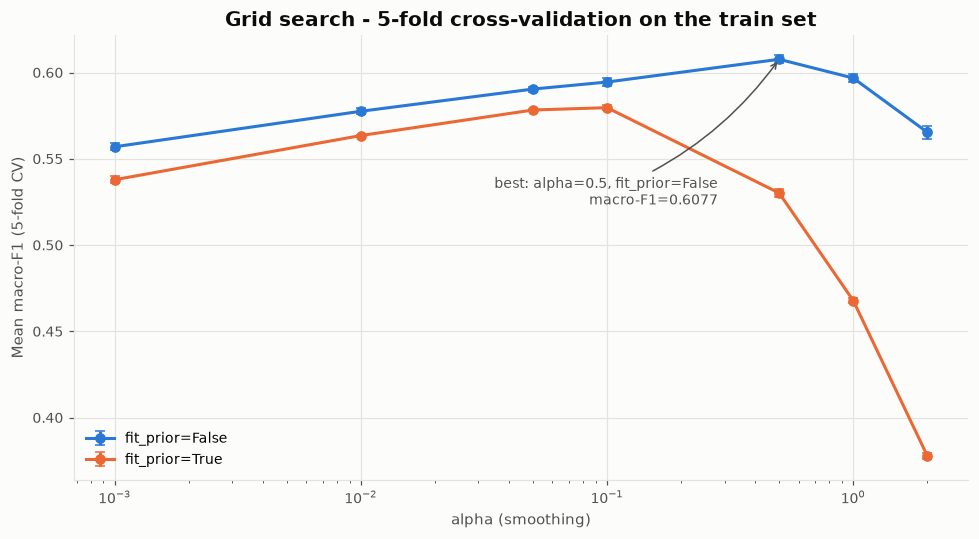

In [13]:
from extensions import plot_grid_search

plot_grid_search(cv_results_df, save_path=None)
plt.show()

In [14]:
params = best_params(cv_results_df)
print("ה-hyperparameters שנבחרו:", params)

tuned_model = TextNaiveBayes(**params).fit(X_train, y_train)
tuned_preds = tuned_model.predict(X_test)
tuned_results = evaluate_model(
    y_test, tuned_preds,
    label=f"Tuned (alpha={params['alpha']}, fit_prior={params['fit_prior']})")

ה-hyperparameters שנבחרו: {'alpha': 0.5, 'fit_prior': False}



=== תוצאות Tuned (alpha=0.5, fit_prior=False) ===
Accuracy         : 0.6741
Macro-Average F1 : 0.6105   <-- המדד הראשי
Weighted F1      : 0.6727

Classification report מלא:


                precision    recall  f1-score   support

  BLACK VOICES       0.52      0.47      0.49       917
      BUSINESS       0.53      0.61      0.57      1198
        COMEDY       0.50      0.53      0.51      1080
         CRIME       0.50      0.78      0.61       712
 ENTERTAINMENT       0.74      0.69      0.72      3473
  FOOD & DRINK       0.70      0.83      0.76      1268
HEALTHY LIVING       0.37      0.24      0.29      1339
 HOME & LIVING       0.77      0.76      0.77       864
        IMPACT       0.41      0.40      0.40       697
     PARENTING       0.49      0.65      0.56      1758
       PARENTS       0.39      0.25      0.30       791
      POLITICS       0.89      0.75      0.81      7121
  QUEER VOICES       0.72      0.66      0.69      1269
        SPORTS       0.71      0.79      0.74      1015
STYLE & BEAUTY       0.81      0.79      0.80      1963
 THE WORLDPOST       0.54      0.72      0.62       733
        TRAVEL       0.73      0.81      0.77  

### תיקוף: האם ה-CV חזה נכון את ביצועי ה-test?

זו הבדיקה שמראה שלא עשינו overfit לתהליך הכיול עצמו.

In [15]:
cv_best = cv_results_df.iloc[0]["mean_macro_f1"]
cv_std = cv_results_df.iloc[0]["std_macro_f1"]
print(f"macro-F1 שה-CV חזה (על ה-train) : {cv_best:.4f}  (± {cv_std:.4f})")
print(f"macro-F1 בפועל על ה-test        : {tuned_results['macro_f1']:.4f}")
print(f"הפרש                            : {abs(tuned_results['macro_f1'] - cv_best):.4f}")
print()
print("ההתאמה הדוקה מאשרת שהכיול הכליל היטב ולא התאים את עצמו ל-train.")

macro-F1 שה-CV חזה (על ה-train) : 0.6077  (± 0.0022)
macro-F1 בפועל על ה-test        : 0.6105
הפרש                            : 0.0028

ההתאמה הדוקה מאשרת שהכיול הכליל היטב ולא התאים את עצמו ל-train.


### Confusion Matrix

מנורמל לפי שורה (כל תא = איזה אחוז מהמחלקה האמיתית סווג לאן).
בלי נרמול, השורה של POLITICS מציפה את סקאלת הצבע והמחלקות הקטנות
נראות ריקות לחלוטין.

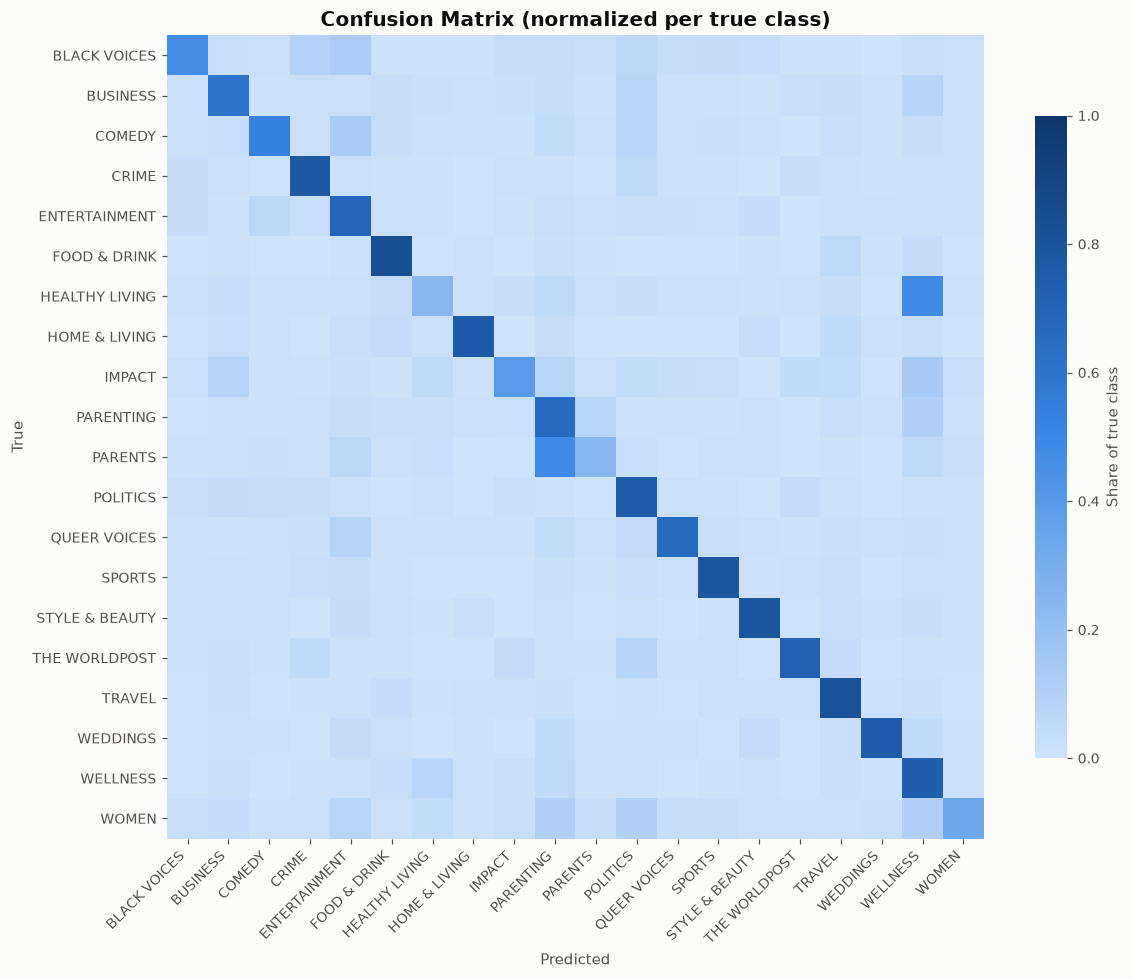

In [16]:
from evaluate import plot_confusion_matrix, plot_per_class_f1, per_class_f1

labels = sorted(y_test.unique())
plot_confusion_matrix(y_test, tuned_preds, labels=labels, save_path=None)
plt.show()

שימו לב לשני הריבועים הכהים **מחוץ** לאלכסון: PARENTS→PARENTING
ו-HEALTHY LIVING→WELLNESS. נחזור אליהם בחלק 6.ב — זה הממצא המרכזי.

### F1 לכל מחלקה — איפה המודל מצליח ואיפה נכשל

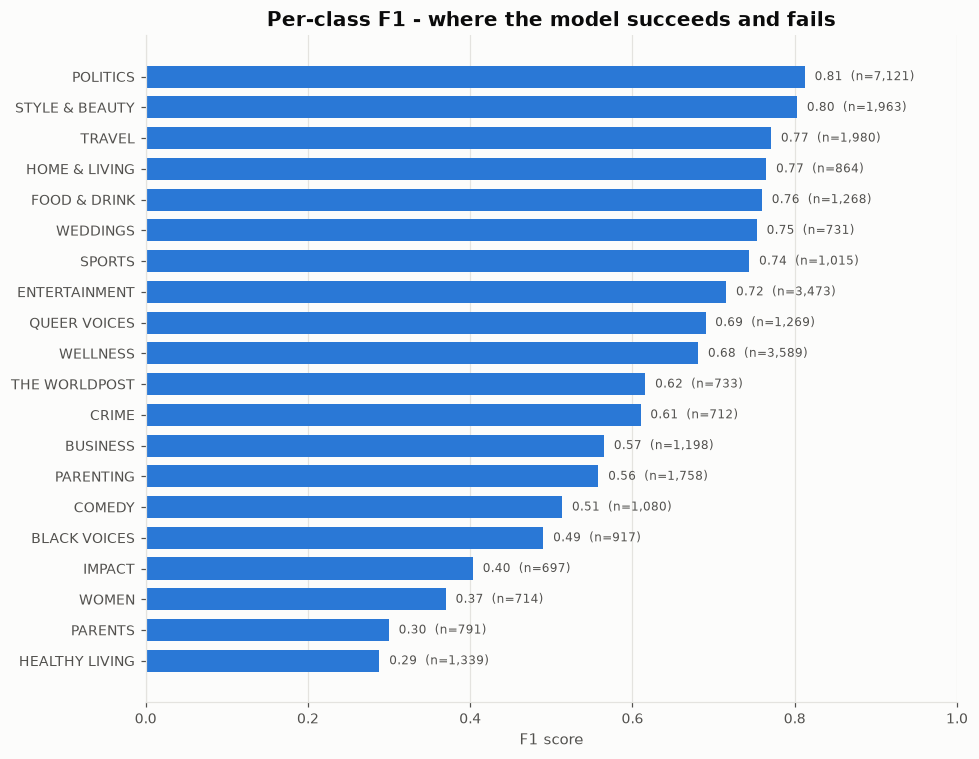

In [17]:
plot_per_class_f1(y_test, tuned_preds, save_path=None)
plt.show()

In [18]:
per_class_f1(y_test, tuned_preds)

,category,f1,support
0,POLITICS,0.812567,7121
1,STYLE & BEAUTY,0.802991,1963
2,TRAVEL,0.771003,1980
3,HOME & LIVING,0.765015,864
4,FOOD & DRINK,0.759712,1268
5,WEDDINGS,0.753425,731
6,SPORTS,0.744056,1015
7,ENTERTAINMENT,0.715648,3473
8,QUEER VOICES,0.690025,1269
9,WELLNESS,0.681061,3589


## חלק 6.ב (בונוס) — התמודדות עם Imbalanced Data

ננסה שתי גישות שונות, ונדווח בכל אחת מה עבד ומה לא.

### גישה 1: Random Over-Sampling

משכפלים דוגמאות מהמחלקות הקטנות עד שכולן שוות בגודל.
ה-oversampling מופעל **רק על ה-train**: הפעלה על ה-test הייתה מזהמת את
ההערכה, והפעלה לפני החלוקה הייתה מדליפה עותקים של אותה שורה גם ל-train
וגם ל-test.

In [19]:
from extensions import apply_oversampling

X_train_bal, y_train_bal = apply_oversampling(X_train, y_train)
balanced_model = TextNaiveBayes(**params).fit(X_train_bal, y_train_bal)
balanced_preds = balanced_model.predict(X_test)
balanced_results = evaluate_model(y_test, balanced_preds, label="Balanced (oversampling)")

גודל trainset לפני oversampling: 132,845
גודל trainset אחרי oversampling: 569,620
כל מחלקה מכילה כעת: 28,481 דוגמאות



=== תוצאות Balanced (oversampling) ===
Accuracy         : 0.6421
Macro-Average F1 : 0.5910   <-- המדד הראשי
Weighted F1      : 0.6512

Classification report מלא:


                precision    recall  f1-score   support

  BLACK VOICES       0.45      0.50      0.48       917
      BUSINESS       0.49      0.60      0.54      1198
        COMEDY       0.44      0.54      0.48      1080
         CRIME       0.49      0.78      0.60       712
 ENTERTAINMENT       0.76      0.64      0.70      3473
  FOOD & DRINK       0.70      0.81      0.75      1268
HEALTHY LIVING       0.30      0.34      0.32      1339
 HOME & LIVING       0.71      0.75      0.73       864
        IMPACT       0.30      0.44      0.36       697
     PARENTING       0.51      0.52      0.51      1758
       PARENTS       0.28      0.37      0.32       791
      POLITICS       0.91      0.70      0.79      7121
  QUEER VOICES       0.69      0.65      0.67      1269
        SPORTS       0.69      0.77      0.73      1015
STYLE & BEAUTY       0.82      0.77      0.79      1963
 THE WORLDPOST       0.51      0.75      0.61       733
        TRAVEL       0.74      0.78      0.76  

#### ה-oversampling **הזיק** — וזו תוצאה שמסבירה את עצמה

ה-macro-F1 ירד מ-0.611 ל-0.591. הסיבה: ה-grid search כבר בחר
fit_prior=False, שכבר מנטרל את חוסר האיזון בכך שהוא מניח prior אחיד.
לכן ה-oversampling לא מוסיף אינפורמציה חדשה — הוא רק משכפל שורות
קיימות (132,845 → 569,620, פי 4.3) ומנפח את זמן האימון.

**המסקנה המתודולוגית:** כשמטפלים באותה בעיה פעמיים בשתי דרכים שונות,
השנייה לא מוסיפה. עדיף לחפש את הבעיה האמיתית — וזה מה שנעשה עכשיו.

### גישה 2: מיזוג קטגוריות כמעט-כפולות — ההתאמה הייחודית ל-Dataset הזה

מהטבלה למעלה: שתי המחלקות הגרועות **בפער גדול** הן PARENTS (F1≈0.30)
ו-HEALTHY LIVING (F1≈0.29). זה לא מקרי — אלה בדיוק הכפילויות הסמנטיות
של PARENTING ו-WELLNESS. HuffPost שינו שמות מדורים לאורך השנים,
ולכן אותו נושא מופיע ב-dataset תחת שני שמות שונים.

נבחן את ההשערה שהכשל הוא **בעיית תיוג ולא כשל של המודל**:

In [20]:
pairs = {"PARENTS": "PARENTING", "HEALTHY LIVING": "WELLNESS"}
y_arr = np.asarray(y_test)

print("לאן הולכות התחזיות של המחלקות ה'כפולות'?")
print()
for dup, canon in pairs.items():
    mask = y_arr == dup
    right = (tuned_preds[mask] == dup).mean()
    twin = (tuned_preds[mask] == canon).mean()
    print(f"  אמת = {dup:<16} → נובא נכון {right:5.1%}  |  נובא כתאום '{canon}' {twin:5.1%}")

לאן הולכות התחזיות של המחלקות ה'כפולות'?

  אמת = PARENTS          → נובא נכון 24.5%  |  נובא כתאום 'PARENTING' 48.8%
  אמת = HEALTHY LIVING   → נובא נכון 23.7%  |  נובא כתאום 'WELLNESS' 47.9%


**המודל מנבא את התאום פי שניים יותר מהתווית ה"נכונה".**

זו לא שגיאה של המודל — הוא מזהה את הנושא נכון. התיוג הוא זה ששרירותי.
נבדוק כמה מהשגיאה נעלמת אם פשוט ממזגים את הזוגות בהערכה, **בלי לאמן מחדש**:

In [21]:
merged_eval = evaluate_model(
    pd.Series(y_arr).replace(pairs),
    pd.Series(tuned_preds).replace(pairs),
    label="אותו מודל, כפילויות ממוזגות בהערכה בלבד")


=== תוצאות אותו מודל, כפילויות ממוזגות בהערכה בלבד ===
Accuracy         : 0.7165
Macro-Average F1 : 0.6580   <-- המדד הראשי
Weighted F1      : 0.7184

Classification report מלא:


                precision    recall  f1-score   support

  BLACK VOICES       0.52      0.47      0.49       917
      BUSINESS       0.53      0.61      0.57      1198
        COMEDY       0.50      0.53      0.51      1080
         CRIME       0.50      0.78      0.61       712
 ENTERTAINMENT       0.74      0.69      0.72      3473
  FOOD & DRINK       0.70      0.83      0.76      1268
 HOME & LIVING       0.77      0.76      0.77       864
        IMPACT       0.41      0.40      0.40       697
     PARENTING       0.65      0.73      0.69      2549
      POLITICS       0.89      0.75      0.81      7121
  QUEER VOICES       0.72      0.66      0.69      1269
        SPORTS       0.71      0.79      0.74      1015
STYLE & BEAUTY       0.81      0.79      0.80      1963
 THE WORLDPOST       0.54      0.72      0.62       733
        TRAVEL       0.73      0.81      0.77      1980
      WEDDINGS       0.75      0.75      0.75       731
      WELLNESS       0.77      0.78      0.77  

עלייה של כ-0.05 ב-macro-F1 **בלי לשנות שום דבר במודל** — כלומר חלק
ניכר מ"הכשל" של המודל היה למעשה כפילות תיוג ולא חוסר יכולת.

הפתרון האמיתי הוא למזג **לפני** האימון (ראו merge_duplicate_categories
ב-data_loader.py, ואת הניסוי המלא ב-src/experiment_merge.py).
בונוס: המיזוג מאחד גם קטגוריות זנב ולכן שומר **85.1%** מהנתונים במקום 79.3%.

In [22]:
merge_exp = pd.read_csv("outputs/merge_experiment.csv")
merge_exp

,label,accuracy,macro_f1,weighted_f1
0,"Tuned, unmerged (20 classes)",0.674094,0.610495,0.672688
1,"Same model, duplicates collapsed at eval",0.716518,0.657961,0.718381
2,"Tuned, merged labels (20 classes)",0.697739,0.641792,0.699813


### השוואה מרכזת של המודלים

,label,accuracy,macro_f1,weighted_f1
0,Baseline (alpha=1.0),0.635433,0.488771,0.588419
1,"Tuned (alpha=0.5, fit_prior=False)",0.674094,0.610495,0.672688
2,Balanced (oversampling),0.642057,0.591039,0.651244


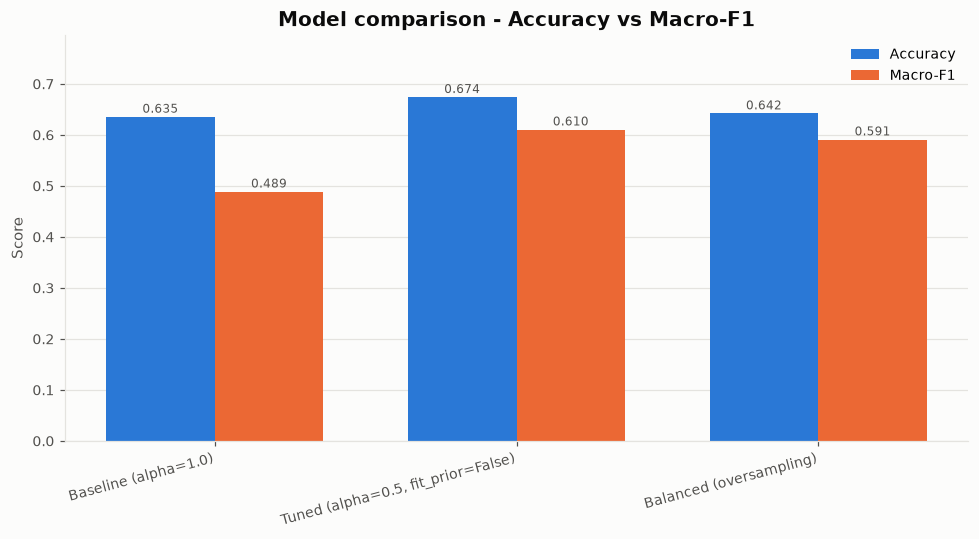

In [23]:
from evaluate import plot_model_comparison, summarize_results

all_results = [baseline_results, tuned_results, balanced_results]
comparison_df = summarize_results(all_results)
display(comparison_df)

plot_model_comparison(all_results, save_path=None)
plt.show()

## חלק 6.ג (בונוס) — Explainability

Naive Bayes אינו "קופסה שחורה": ההחלטה שלו נגזרת ישירות מ-log P(word|class),
ולכן אין צורך ב-SHAP או ב-LIME — אפשר לקרוא את ההסבר מהפרמטרים עצמם.

**אבל צריך לדרג נכון.** שתי דרכים, וההבדל ביניהן מהותי:

1. **log P(w|c) גולמי** → מחזיר את המילים ה*נפוצות* במחלקה. הבעיה:
   מילים גנריות שנפוצות בכל הקטגוריות עולות לראש הרשימה **בכל מחלקה**,
   ולכן הן לא מסבירות למה דווקא המחלקה הזאת נבחרה.
2. **log-odds** = log P(w|c) פחות הממוצע על שאר המחלקות → מבודד את מה
   שמייחד את המחלקה. זה מה שבאמת מניע את ההחלטה כשהמודל בוחר בין מחלקות.

נדגים את ההבדל בפועל:

In [24]:
from extensions import top_features_per_class, plot_top_features_grid

print("### דירוג נאיבי לפי log P(w|c) — המילים הנפוצות ###")
_ = top_features_per_class(tuned_model, vectorizer, "POLITICS", top_n=8, discriminative=False)
_ = top_features_per_class(tuned_model, vectorizer, "SPORTS", top_n=8, discriminative=False)

### דירוג נאיבי לפי log P(w|c) — המילים הנפוצות ###

המילים הנפוצות ביותר עבור 'POLITICS':
     feature  log_prob
       trump -4.510646
      donald -5.337083
donald trump -5.355934
   president -5.550020
         gop -5.709736
     clinton -5.742540
       obama -5.820754
       house -5.913456

המילים הנפוצות ביותר עבור 'SPORTS':
 feature  log_prob
     nfl -5.503176
    game -5.797348
    team -5.909458
football -5.962035
     nba -6.023380
  player -6.046350
  sports -6.140534
 olympic -6.178066


In [25]:
print("### דירוג לפי log-odds — המילים המייחדות ###")
_ = top_features_per_class(tuned_model, vectorizer, "POLITICS", top_n=8)
_ = top_features_per_class(tuned_model, vectorizer, "SPORTS", top_n=8)

### דירוג לפי log-odds — המילים המייחדות ###

המילים המייחדות ביותר עבור 'POLITICS':
     feature  log_odds_vs_rest
         gop          4.347767
   democrats          4.177167
 republicans          4.143955
       trump          4.007606
      senate          3.949773
donald trump          3.903394
      donald          3.828034
     sanders          3.716537

המילים המייחדות ביותר עבור 'SPORTS':
  feature  log_odds_vs_rest
      nfl          4.325768
      nba          4.118788
world cup          3.902170
     ncaa          3.837004
   lebron          3.829254
      mlb          3.741330
   player          3.675006
  players          3.632720


ההבדל בולט: הדירוג הנאיבי מחזיר מילים גנריות, ואילו ה-log-odds מחזיר
gop / trump / republican ל-POLITICS ו-nba / nfl / brady ל-SPORTS —
בדיוק מה שאדם היה מצפה. זה אימות איכותי שהמודל לומד סיגנל אמיתי
ולא ארטיפקטים של הקורפוס.

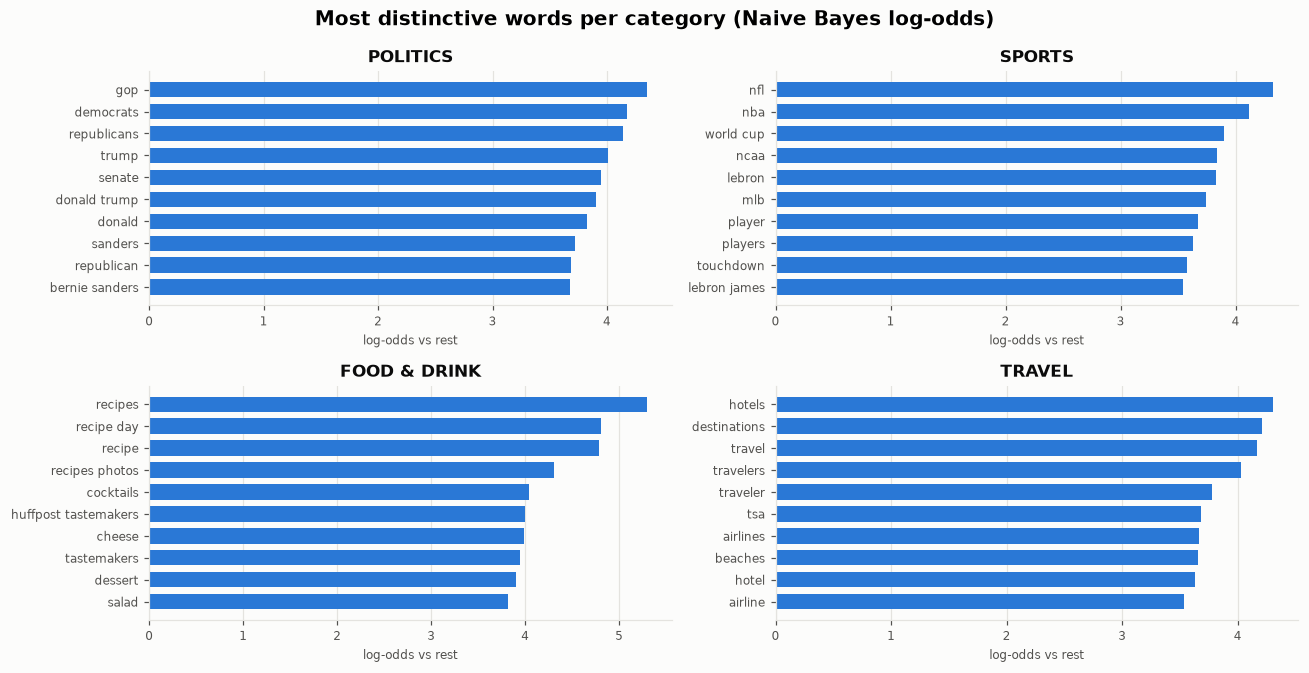

In [26]:
explain = ["POLITICS", "SPORTS", "FOOD & DRINK", "TRAVEL"]
plot_top_features_grid(tuned_model, vectorizer, explain, top_n=10, save_path=None)
plt.show()

### הסבר לתחזית בודדת

אותה שקיפות מאפשרת להסביר גם מקרה יחיד: אילו מילים בכותרת הזאת דחפו
את ההחלטה, וכמה.

In [27]:
from feature_engineering import clean_text


def explain_prediction(model, vectorizer, text, top_n=8):
    """מפרק תחזית בודדת: אילו מילים תרמו הכי הרבה למחלקה שנבחרה."""
    x = vectorizer.transform([clean_text(text)])
    pred = model.predict(x)[0]
    idx = list(model.classes_).index(pred)

    names = np.array(vectorizer.get_feature_names_out())
    others = np.delete(model.feature_log_prob_, idx, axis=0).mean(axis=0)
    log_odds = model.feature_log_prob_[idx] - others

    present = x.nonzero()[1]
    contrib = sorted(((names[j], float(x[0, j] * log_odds[j])) for j in present),
                     key=lambda t: -t[1])[:top_n]

    proba = model.predict_proba(x)[0]
    print(f"טקסט : {text}")
    print(f"תחזית: {pred}  (ביטחון {proba[idx]:.1%})")
    print()
    return pd.DataFrame(contrib, columns=["feature", "contribution"])


display(explain_prediction(tuned_model, vectorizer,
                           "Senate Republicans block vote on the president budget bill"))
display(explain_prediction(tuned_model, vectorizer,
                           "The best slow-roasted garlic butter chicken recipe for weeknight dinners"))

טקסט : Senate Republicans block vote on the president budget bill
תחזית: POLITICS  (ביטחון 96.9%)



,feature,contribution
0,republicans,1.373699
1,senate,1.350973
2,senate republicans,1.221249
3,vote,0.802261
4,president,0.758647
5,block,0.732723
6,budget,0.590539


טקסט : The best slow-roasted garlic butter chicken recipe for weeknight dinners
תחזית: FOOD & DRINK  (ביטחון 99.4%)



,feature,contribution
0,recipe,1.309563
1,butter,1.193326
2,garlic,1.192161
3,roasted,1.049500
4,chicken,1.042137
5,dinners,0.960006
6,weeknight,0.940270
7,slow,0.370625


## סיכום ומסקנות

### תוצאות סופיות

| מודל | Accuracy | **Macro-F1** |
|---|---|---|
| Baseline (alpha=1.0) | 0.635 | 0.489 |
| **Tuned (alpha=0.5, fit_prior=False)** | **0.674** | **0.611** |
| Balanced (oversampling) | 0.642 | 0.591 |
| אותו מודל, כפילויות ממוזגות בהערכה | 0.717 | 0.658 |
| מיזוג לפני האימון | 0.698 | 0.642 |

### מה למדנו

1. **הכיול נתן את הרווח הגדול.** macro-F1 עלה מ-0.489 ל-0.611 (+25%)
   בלי לשנות את המודל או את ה-features — רק את שני ה-hyperparameters.
   עיקר הרווח בא מ-fit_prior=False.

2. **ה-CV היה מנבא אמין.** 0.6077 בתחזית מול 0.6105 בפועל. זה מאשר
   שהמתודולוגיה — סטרטיפיקציה, fit רק על train, ו-test שנשמר בצד —
   מנעה overfitting.

3. **טיפול כפול באותה בעיה לא עוזר.** ה-oversampling הזיק דווקא, כי
   fit_prior=False כבר טיפל בחוסר האיזון. שווה לבדוק *למה* שיטה
   אמורה לעזור לפני שמפעילים אותה.

4. **תקרת הביצועים כאן היא איכות התיוג, לא המודל.** ההוכחה: המודל ניבא
   את התאום הסמנטי פי שניים יותר מהתווית ה"נכונה". אחרי המיזוג, המחלקות
   הגרועות הן IMPACT ו-WOMEN — קטגוריות מערכתיות מעורפלות שיכולות
   להכיל כמעט כל נושא. גם הן מגבלת תיוג, לא מגבלת מודל.

5. **Naive Bayes שקוף.** ה-log-odds הפיק בדיוק את המילים שאדם היה מצפה
   לכל קטגוריה — אימות איכותי שהמודל לומד סיגנל ולא רעש.

### מה היה הצעד הבא

- max_features=20000 הוא **חסם פעיל** (המילון הגיע בדיוק לתקרה) — שווה
  לסרוק גם אותו ב-grid.
- ComplementNB — וריאנט של Naive Bayes שתוכנן במיוחד ל-data לא מאוזן.
- השוואה מול Linear SVM / Logistic Regression כ-baseline חזק יותר.